Bài tập 1: Thống kê theo nhóm

In [4]:
import pandas as pd

df = pd.read_csv("data/sinh_vien.csv")

nhom_cao = df[df["diem_giua_ky"] >= 7]
nhom_con_lai = df[df["diem_giua_ky"] < 7]

print("So ban co diem giua ky tu 7 tro len:", len(nhom_cao))
print("Ty le qua mon cua nhom diem giua ky >= 7:", round(nhom_cao["qua_mon"].mean(), 4))
print("Ty le qua mon cua nhom con lai:", round(nhom_con_lai["qua_mon"].mean(), 4))
print("Nhan xet: Diem giua ky phan biet rat tot hai nhom vi nhom co diem giua ky tu 7 tro len co ty le qua mon dat 90.32% (28 tren 31 ban), cao hon vuot troi so voi nhom con lai chi dat 48.31% (43 tren 89 ban).")

So ban co diem giua ky tu 7 tro len: 31
Ty le qua mon cua nhom diem giua ky >= 7: 0.9032
Ty le qua mon cua nhom con lai: 0.4831
Nhan xet: Diem giua ky phan biet rat tot hai nhom vi nhom co diem giua ky tu 7 tro len co ty le qua mon dat 90.32% (28 tren 31 ban), cao hon vuot troi so voi nhom con lai chi dat 48.31% (43 tren 89 ban).


Bài tập 2: Vẽ hàm sigmoid

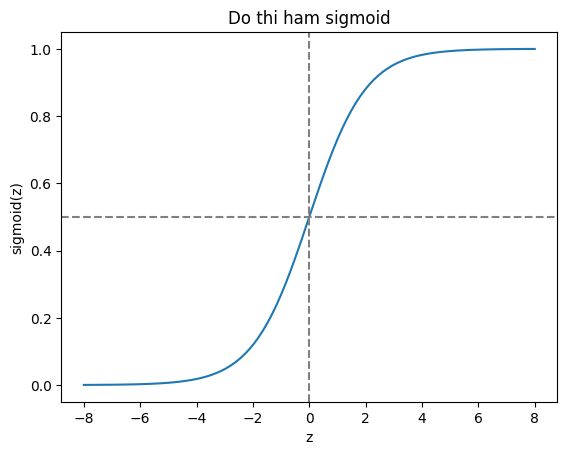

In [5]:
import matplotlib.pyplot as plt
import numpy as np

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z = np.linspace(-8, 8, 200)
sig = sigmoid(z)

plt.plot(z, sig)
plt.axhline(0.5, color="gray", linestyle="--")
plt.axvline(0, color="gray", linestyle="--")
plt.xlabel("z")
plt.ylabel("sigmoid(z)")
plt.title("Do thi ham sigmoid")

plt.savefig("sigmoid.png", dpi=150)
plt.show()

Bài tập 3: Dự đoán cho một bạn cụ thể

In [6]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression

df = pd.read_csv("data/sinh_vien.csv")
X = df[["gio_on"]]
y = df["qua_mon"]

mo_hinh = LogisticRegression()
mo_hinh.fit(X, y)

w = float(mo_hinh.coef_[0][0])
b = float(mo_hinh.intercept_[0])

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def du_doan(gio):
    z = w * gio + b
    xac_suat = sigmoid(z)
    nhan = 1 if xac_suat >= 0.5 else 0
    print(f"Gio on: {gio:5.2f} -> z = {z:7.4f}, xac suat = {xac_suat:.4f}, nhan = {nhan}")

for g in [3, 8, 12.89, 18, 26]:
    du_doan(g)

print()
print("Giai thich: Voi 12.89 gio, gia tri z = 0.392819 * 12.89 - 5.064890 xap xi bang 0 (-0.0015). Vi sigmoid(0) = 0.5, nen xac suat qua mon tai moc 12.89 gio ra gan dung 0.5 (chinh xac la 0.4996).")

Gio on:  3.00 -> z = -3.8864, xac suat = 0.0201, nhan = 0
Gio on:  8.00 -> z = -1.9223, xac suat = 0.1276, nhan = 0
Gio on: 12.89 -> z = -0.0015, xac suat = 0.4996, nhan = 0
Gio on: 18.00 -> z =  2.0059, xac suat = 0.8814, nhan = 1
Gio on: 26.00 -> z =  5.1484, xac suat = 0.9942, nhan = 1

Giai thich: Voi 12.89 gio, gia tri z = 0.392819 * 12.89 - 5.064890 xap xi bang 0 (-0.0015). Vi sigmoid(0) = 0.5, nen xac suat qua mon tai moc 12.89 gio ra gan dung 0.5 (chinh xac la 0.4996).


Bài tập 4: Tự tính bốn thước đo

In [7]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split

df = pd.read_csv("data/sinh_vien.csv")
X = df[["gio_on"]]
y = df["qua_mon"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=17, stratify=y
)

mo_hinh = LogisticRegression()
mo_hinh.fit(X_train, y_train)
y_pred = mo_hinh.predict(X_test)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

acc = (tp + tn) / (tp + tn + fp + fn)
pre = tp / (tp + fp)
rec = tp / (tp + fn)
f1 = 2 * (pre * rec) / (pre + rec)

print("Ma tran nham lan:")
print(f"TN = {tn}, FP = {fp}, FN = {fn}, TP = {tp}")
print()
print(f"Accuracy  = ({tp} + {tn}) / ({tp} + {tn} + {fp} + {fn}) = {acc:.4f}")
print(f"Precision = {tp} / ({tp} + {fp}) = {pre:.4f}")
print(f"Recall    = {tp} / ({tp} + {fn}) = {rec:.4f}")
print(f"F1        = 2 * ({pre:.4f} * {rec:.4f}) / ({pre:.4f} + {rec:.4f}) = {f1:.4f}")
print()
print("Ket luan: Cac ket qua tu tinh bang bon so TP, TN, FP, FN khop hoan toan voi ket qua in trong tai lieu (Accuracy = 0.8667, Precision = 0.8500, Recall = 0.9444, F1 = 0.8947).")

Ma tran nham lan:
TN = 9, FP = 3, FN = 1, TP = 17

Accuracy  = (17 + 9) / (17 + 9 + 3 + 1) = 0.8667
Precision = 17 / (17 + 3) = 0.8500
Recall    = 17 / (17 + 1) = 0.9444
F1        = 2 * (0.8500 * 0.9444) / (0.8500 + 0.9444) = 0.8947

Ket luan: Cac ket qua tu tinh bang bon so TP, TN, FP, FN khop hoan toan voi ket qua in trong tai lieu (Accuracy = 0.8667, Precision = 0.8500, Recall = 0.9444, F1 = 0.8947).


Bài tập 5: Dò ngưỡng tốt nhất theo F1

In [8]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split

df = pd.read_csv("data/sinh_vien.csv")
X = df[["gio_on"]]
y = df["qua_mon"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=17, stratify=y
)

mo_hinh = LogisticRegression().fit(X_train, y_train)
p = mo_hinh.predict_proba(X_test)[:, 1]

nguong_list = np.arange(0.05, 1.0, 0.05)
best_f1 = -1
best_nguong = 0.0

print("Nguong       F1")
for ng in nguong_list:
    y_pred_ng = (p >= ng).astype(int)
    f1 = f1_score(y_test, y_pred_ng, zero_division=0)
    print(f"  {ng:.2f}   {f1:.4f}")
    if f1 > best_f1:
        best_f1 = f1
        best_nguong = ng

print()
print(f"Nguong cho F1 cao nhat: {best_nguong:.2f} voi F1 = {best_f1:.4f}")
print("Nhan xet: Nguong tot nhat theo F1 khong phai bang 0.5 ma la 0.60 (va 0.65) voi F1 dat 0.9412, cao hon muc F1 = 0.8947 o nguong mac dinh 0.5. Do do, nguong 0.5 chi la mac dinh chu khong phai luon la nguong toi uu nhat.")

Nguong       F1
  0.05   0.7826
  0.10   0.8182
  0.15   0.8182
  0.20   0.8571
  0.25   0.9000
  0.30   0.8947
  0.35   0.8947
  0.40   0.8947
  0.45   0.8947
  0.50   0.8947
  0.55   0.8889
  0.60   0.9412
  0.65   0.9412
  0.70   0.9091
  0.75   0.8750
  0.80   0.8387
  0.85   0.8000
  0.90   0.5600
  0.95   0.4348

Nguong cho F1 cao nhat: 0.60 voi F1 = 0.9412
Nhan xet: Nguong tot nhat theo F1 khong phai bang 0.5 ma la 0.60 (va 0.65) voi F1 dat 0.9412, cao hon muc F1 = 0.8947 o nguong mac dinh 0.5. Do do, nguong 0.5 chi la mac dinh chu khong phai luon la nguong toi uu nhat.


Bài tập 6: Đổi lớp dương rồi chấm lại

In [9]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score
from sklearn.model_selection import train_test_split

df = pd.read_csv("data/sinh_vien.csv")
X = df[["gio_on"]]
y = df["qua_mon"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=17, stratify=y
)

mo_hinh = LogisticRegression().fit(X_train, y_train)
y_pred = mo_hinh.predict(X_test)

pre_0 = precision_score(y_test, y_pred, pos_label=0)
rec_0 = recall_score(y_test, y_pred, pos_label=0)

pre_1 = precision_score(y_test, y_pred, pos_label=1)
rec_1 = recall_score(y_test, y_pred, pos_label=1)

print("Ket qua cham diem theo tung lop:")
print(f"Lop 0 (rot mon): Precision = {pre_0:.4f}, Recall = {rec_0:.4f}")
print(f"Lop 1 (qua mon): Precision = {pre_1:.4f}, Recall = {rec_1:.4f}")
print()
print("Giai thich: Hai bo so khac nhau vi khi doi pos_label sang 0 thi lop duoc quan tam da doi tu qua mon sang rot mon. Khi do vai tro cac o trong ma tran nham lan bi hoan doi: TP cua lop 0 chinh la TN cua lop 1 (9 ban), FP cua lop 0 la FN cua lop 1 (1 ban), va FN cua lop 0 la FP cua lop 1 (3 ban). Mau so va tu so cua cong thuc thay doi theo goc nhin cua lop 0 nen ket qua Precision va Recall khac han.")

Ket qua cham diem theo tung lop:
Lop 0 (rot mon): Precision = 0.9000, Recall = 0.7500
Lop 1 (qua mon): Precision = 0.8500, Recall = 0.9444

Giai thich: Hai bo so khac nhau vi khi doi pos_label sang 0 thi lop duoc quan tam da doi tu qua mon sang rot mon. Khi do vai tro cac o trong ma tran nham lan bi hoan doi: TP cua lop 0 chinh la TN cua lop 1 (9 ban), FP cua lop 0 la FN cua lop 1 (1 ban), va FN cua lop 0 la FP cua lop 1 (3 ban). Mau so va tu so cua cong thuc thay doi theo goc nhin cua lop 0 nen ket qua Precision va Recall khac han.
